### Identify percentage of disease DEGs that are fetalization

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
fetalization_df <- read.csv("04A_intersect_analysis_results.csv", row.names = 1)

In [3]:
cell_types <- c("Cardiomyocyte", "Endothelial", "Fibroblast", "LEC", "Lymphoid", "Myeloid", "Neuronal", "Pericyte")
disease_subtypes <- c("DCM", "HCM", "ICM")

In [4]:
results_list <- list()  # empty list to collect rows
i <- 1

for (cell_type in cell_types) {
  for (disease in disease_subtypes) { 
    
    # subset fetalization data
    filt_df <- fetalization_df[
      (fetalization_df$contrast1 == disease) & 
      (fetalization_df$cell_type == cell_type), 
    ]
    
    # read disease DEGs
    df <- read.csv(
      paste0("pydeseq2_results/", cell_type, "_disease_", disease, "_vs_ND_results.csv")
    )
    
    up_DEGs <- sum(df$significant == "True" & df$log2FoldChange > 0)
    down_DEGs <- sum(df$significant == "True" & df$log2FoldChange < 0)
    
    fetal_up <- filt_df$up_both
    fetal_down <- filt_df$down_both
    
    prop_fetal_up <- ifelse(up_DEGs > 0, fetal_up / up_DEGs, NA)
    prop_fetal_down <- ifelse(down_DEGs > 0, fetal_down / down_DEGs, NA)
    
    # store results as a row
    results_list[[i]] <- data.frame(
      cell_type = cell_type,
      disease = disease,
      up_DEGs = up_DEGs,
      down_DEGs = down_DEGs,
      fetal_up = fetal_up,
      fetal_down = fetal_down,
      prop_fetal_up = prop_fetal_up,
      prop_fetal_down = prop_fetal_down
    )
    i <- i + 1
  }
}

In [5]:
results_df <- do.call(rbind, results_list)

In [6]:
results_long <- results_df %>%
  select(cell_type, disease, up_DEGs, down_DEGs, fetal_up, fetal_down, 
         prop_fetal_up, prop_fetal_down) %>%
  pivot_longer(
    cols = c(prop_fetal_up, prop_fetal_down),
    names_to = "direction",
    values_to = "prop"
  ) %>%
  mutate(direction = recode(direction,
                            "prop_fetal_up" = "up",
                            "prop_fetal_down" = "down"))

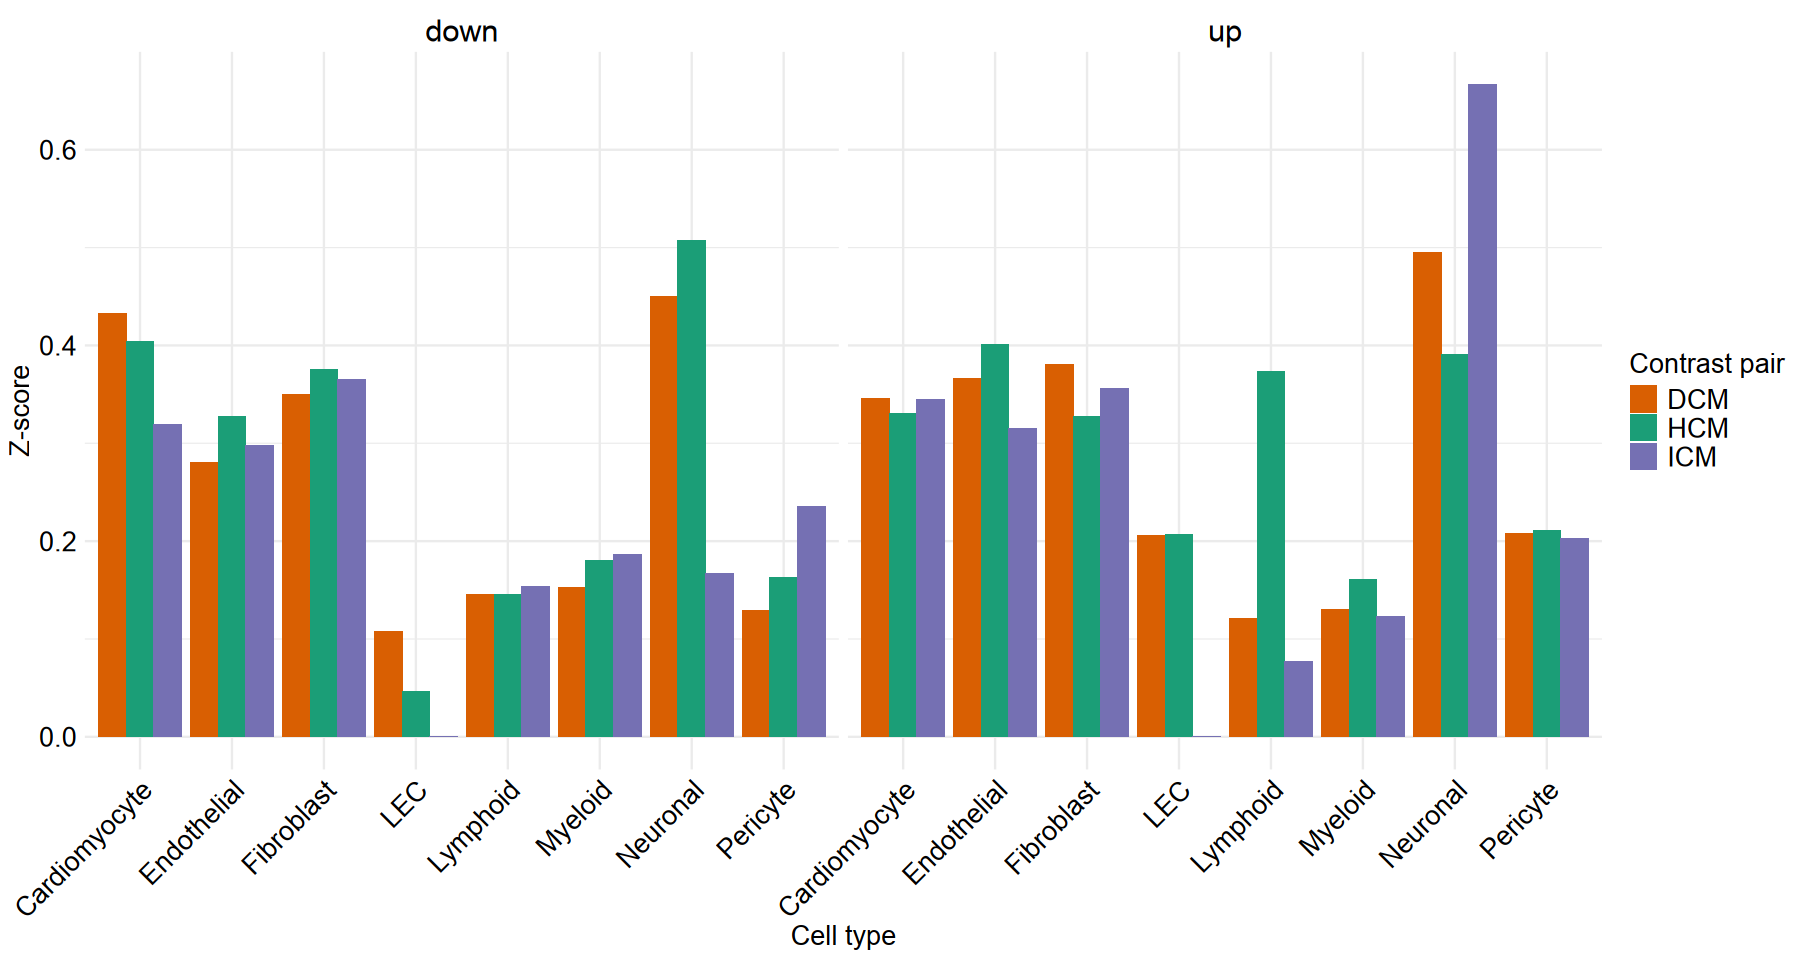

In [8]:
options(repr.plot.width = 15, repr.plot.height = 8)

p1 <- ggplot(data = results_long,
       mapping = aes(x = cell_type, y = prop, fill = disease)) + facet_wrap(~ direction) + 
  geom_bar(stat = "identity", position = position_dodge()) +
  scale_fill_manual(values = c(
    "HCM"   = "#1B9E77",
    "DCM"     = "#D95F02",
    "ICM" = "#7570B3"
  )) +
  theme_minimal() + 
  labs(x = "Cell type", y = "Z-score", fill = "Contrast pair") +
theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black", angle = 45, hjust = 1),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(plot = p1, filename = "04C_proportion_of_fetalization_DEGs.pdf", width = 15, height = 8)

p1